In [1]:
!pip install ultralytics roboflow
import ultralytics
ultralytics.checks() # Verifies that the GPU is active

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nCbCCIDK7LcKxyJP7ELO")
project = rf.workspace("lzys-project").project("pku-pcb-s5xtk")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pku-pcb-1 in yolov8:: 100%|██████████| 6664/6664 [00:00<00:00, 7030.19it/s]


In [3]:
from ultralytics import YOLO

# Initialize the lightweight edge model
model = YOLO('yolov8n.pt')

# Start GPU training
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="pcb_defect",
    name="v1_run"
)

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pku-pcb-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_run, nbs=64, nms=False, opset=N

In [4]:
!cat /content/pku-pcb-1/data.yaml

names:
- '- collaborate with your team on computer vision projects'
- '------------------------------'
- ==============================
- Roboflow is an end-to-end computer vision platform that helps you
- pku-pcb - v1 2025-03-16 6-17pm
- pku-pcb - v1 2025-03-16 6:17pm
nc: 6
roboflow:
  license: CC BY 4.0
  project: pku-pcb-s5xtk
  url: https://universe.roboflow.com/lzys-project/pku-pcb-s5xtk/dataset/1
  version: 1
  workspace: lzys-project
test: ../test/images
train: ../train/images
val: ../valid/images


In [5]:
!ls /content/pku-pcb-1/train/labels | head -n 1 | xargs -I {} cat /content/pku-pcb-1/train/labels/{}

4 0.3015625 0.0921875 0.021875 0.0390625
4 0.33984375 0.38125 0.0234375 0.0375
2 0.7796875 0.20703125 0.0328125 0.0328125
2 0.859375 0.4234375 0.0328125 0.025
2 0.7328125 0.69375 0.025 0.0171875
2 0.8625 0.678125 0.0140625 0.0359375
2 0.92109375 0.92109375 0.0171875 0.04375
2 0.68984375 0.96796875 0.015625 0.0328125

In [6]:
yaml_content = """
train: /content/pku-pcb-1/train/images
val: /content/pku-pcb-1/valid/images
test: /content/pku-pcb-1/test/images

nc: 6
names: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
"""

with open('/content/pku-pcb-1/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("data.yaml has been fixed!")

data.yaml has been fixed!


In [7]:
rm -rf /content/pku-pcb-1/train/labels.cache

In [8]:
rm -rf /content/pku-pcb-1/valid/labels.cache

In [9]:
!ls /content/pku-pcb-1/train/
!ls /content/pku-pcb-1/valid/

images	labels
images	labels


In [10]:
!cat /content/pku-pcb-1/data.yaml

train: /content/pku-pcb-1/train/images
val: /content/pku-pcb-1/valid/images
test: /content/pku-pcb-1/test/images

nc: 6
names: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']

In [11]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/pku-pcb-1/data.yaml epochs=100 imgsz=640 patience=20 project=pcb_defect name=v2_run

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pku-pcb-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v2_run, nbs=64, nms=False, opset=

In [12]:
!ls /content/pku-pcb-1/train/labels/ | head -5

01_missing_hole_01_jpg.rf.3a4157a0ddd4f81dc48a6d62f87dbe41.txt
01_missing_hole_01_jpg.rf.7484b643a9af3d10eb2b887b2b6c2d60.txt
01_missing_hole_01_jpg.rf.783fab64964478a4230464467bb25a23.txt
01_missing_hole_01_jpg.rf.8e64ed4b687439424c5575dab82a5fa6.txt
01_missing_hole_01_jpg.rf.f676747dd184bffc80f6f35fe8e3c63b.txt


In [13]:
!cat "/content/pku-pcb-1/train/labels/01_missing_hole_01_jpg.rf.3a4157a0ddd4f81dc48a6d62f87dbe41.txt"

4 0.3015625 0.0921875 0.021875 0.0390625
4 0.33984375 0.38125 0.0234375 0.0375
2 0.7796875 0.20703125 0.0328125 0.0328125
2 0.859375 0.4234375 0.0328125 0.025
2 0.7328125 0.69375 0.025 0.0171875
2 0.8625 0.678125 0.0140625 0.0359375
2 0.92109375 0.92109375 0.0171875 0.04375
2 0.68984375 0.96796875 0.015625 0.0328125

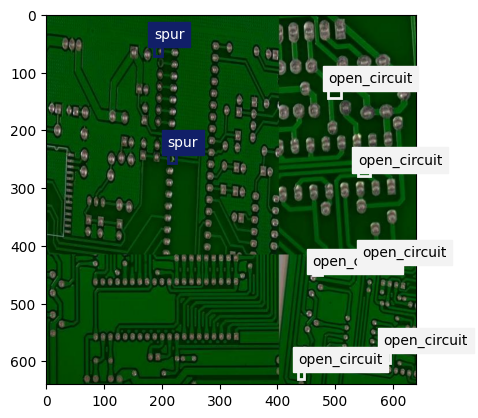

In [14]:
from ultralytics.data.utils import visualize_image_annotations

visualize_image_annotations(
    "/content/pku-pcb-1/train/images/01_missing_hole_01_jpg.rf.3a4157a0ddd4f81dc48a6d62f87dbe41.jpg",
    "/content/pku-pcb-1/train/labels/01_missing_hole_01_jpg.rf.3a4157a0ddd4f81dc48a6d62f87dbe41.txt",
    label_map={0:'missing_hole',1:'mouse_bite',2:'open_circuit',3:'short',4:'spur',5:'spurious_copper'}
)

In [15]:
import os
import random

label_dir = '/content/pku-pcb-1/train/labels'
# The 6 correct classes mapped to their IDs
class_map = {0: 'missing_hole', 1: 'mouse_bite', 2: 'open_circuit', 3: 'short', 4: 'spur', 5: 'spurious_copper'}

# Grab 5 random label files
all_labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
samples = random.sample(all_labels, 5)

for label_file in samples:
    print(f"\nFilename: {label_file}")
    with open(os.path.join(label_dir, label_file), 'r') as f:
        lines = f.readlines()
        if not lines:
            print("  -> EMPTY LABEL FILE (No defects annotated)")
            continue

        found_classes = set()
        for line in lines:
            class_id = int(line.split()[0])
            found_classes.add(class_map.get(class_id, f"UNKNOWN_ID_{class_id}"))

        print(f"  -> Actual labels inside: {', '.join(found_classes)}")


Filename: 06_open_circuit_09_jpg.rf.fe48a16469bb9985cbfdd6e160982d16.txt
  -> Actual labels inside: short, open_circuit

Filename: 08_spurious_copper_10_jpg.rf.a3371f9e04c95ca347fea8c180470bbe.txt
  -> Actual labels inside: missing_hole, spurious_copper

Filename: 05_missing_hole_02_jpg.rf.7f6b69ca5f77fb0602a6e2bb701daac9.txt
  -> Actual labels inside: mouse_bite, spur

Filename: 05_open_circuit_09_jpg.rf.6d0eeebf238735fd069150c5b1253eae.txt
  -> Actual labels inside: short, open_circuit

Filename: 09_mouse_bite_01_jpg.rf.199df31d48241c089f3670dc9f8c2b36.txt
  -> Actual labels inside: missing_hole, mouse_bite, short


In [16]:
rm -rf /content/pku-pcb-1
rm -rf /content/runs/detect/pcb_defect/v1_run
rm -rf /content/runs/detect/pcb_defect/v2_run

NameError: name 'rm' is not defined

In [17]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d liuxiaolong1/pcb-defect-detection-dataset
!unzip -q pcb-defect-detection-dataset.zip -d /content/pcb_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/liuxiaolong1/pcb-defect-detection-dataset
License(s): CC0-1.0
100% 9.62G/9.62G [08:25<00:00, 20.4MB/s]



In [18]:
!unzip -l pcb-defect-detection-dataset.zip | head -n 15

Archive:  pcb-defect-detection-dataset.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
       53  2025-03-14 02:04   DeepPCB/Class.txt
    18783  2025-03-14 02:04   DeepPCB/test/images/01_PCB__101.jpg
    16927  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1019.jpg
    39024  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1044.jpg
    21366  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1047.jpg
    10645  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1053.jpg
    32215  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1057.jpg
    60912  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1078.jpg
    33333  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1082.jpg
    26719  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1085.jpg
    15842  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1100.jpg
    20822  2025-03-14 02:04   DeepPCB/test/images/01_PCB__1115.jpg


In [22]:
!unzip -qo pcb-defect-detection-dataset.zip "DeepPCB/*" -d /content/pcb_data

In [23]:
!unzip -qo pcb-defect-detection-dataset.zip "DeepPCB/*" -d /content/pcb_data

In [24]:
!rm pcb-defect-detection-dataset.zip

In [25]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Paths to the clean DeepPCB dataset
image_dir = '/content/pcb_data/DeepPCB/train/images'
label_dir = '/content/pcb_data/DeepPCB/train/labels'

# Load classes from Class.txt
with open('/content/pcb_data/DeepPCB/Class.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255), (0,255,255)]

images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]
samples = random.sample(images, 3)

plt.figure(figsize=(15, 5))

for i, img_name in enumerate(samples):
    img_path = os.path.join(image_dir, img_name)
    lbl_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                # The traceback context shows '94 287 181 352 1'
                # This indicates format: class_id center_x center_y width height (all in pixels)
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    pcx, pcy, pbw, pbh = map(float, parts[1:]) # pixel center x,y and pixel width, height

                    # Convert pixel center/width/height to xmin, ymin, xmax, ymax
                    x1 = int(pcx - pbw / 2)
                    y1 = int(pcy - pbh / 2)
                    x2 = int(pcx + pbw / 2)
                    y2 = int(pcy + pbh / 2)

                    # Ensure coordinates are within image bounds
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w, x2)
                    y2 = min(h, y2)

                    # Use cls_id directly. If cls_id is out of bounds for the 'classes' list,
                    # provide a warning and use a generic name.
                    if cls_id < len(classes):
                        class_name = classes[cls_id]
                    else:
                        class_name = f"Unknown Class {cls_id}"
                        print(f"Warning: Class ID {cls_id} found in {lbl_path} for image {img_name} is out of range for defined classes.")

                    cv2.rectangle(img, (x1, y1), (x2, y2), colors[cls_id % len(colors)], 2)
                    cv2.putText(img, class_name, (x1, max(y1 - 5, 15)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[cls_id % len(colors)], 2)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

IndexError: list index out of range

<Figure size 1500x500 with 0 Axes>

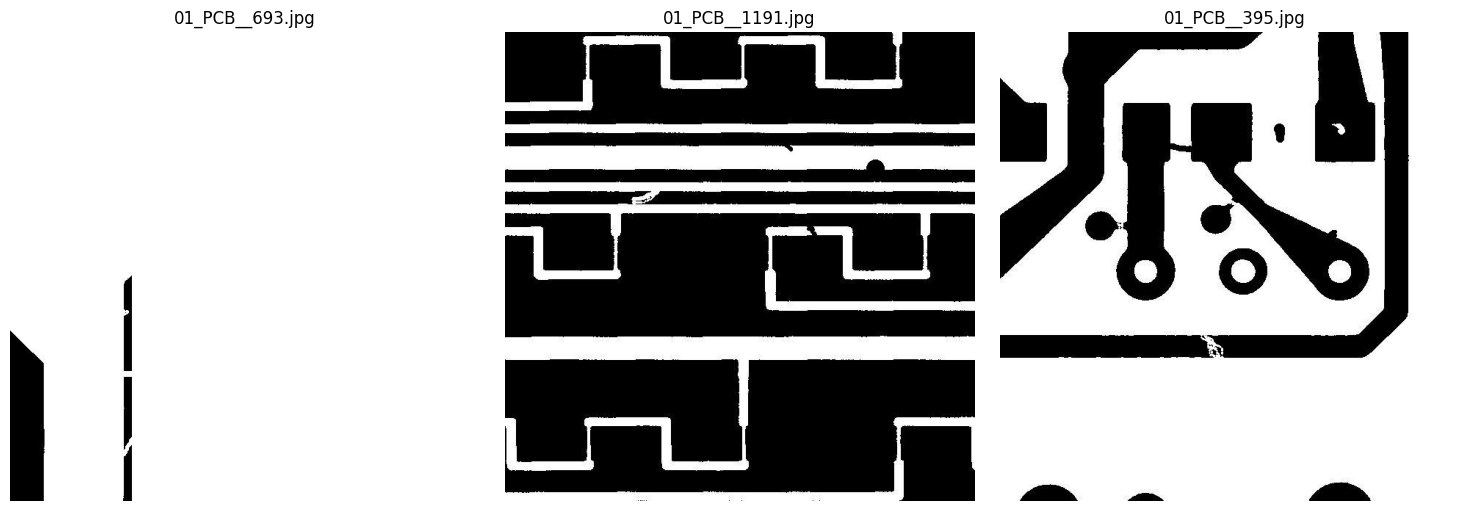

In [27]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Paths to the clean DeepPCB dataset
image_dir = '/content/pcb_data/DeepPCB/train/images'
label_dir = '/content/pcb_data/DeepPCB/train/labels'

# DeepPCB Classes (Let's make sure we catch unexpected IDs safely)
classes = ['Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']
colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (0,255,255), (255,0,255)]

images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]
samples = random.sample(images, 3)

plt.figure(figsize=(15, 5))

for i, img_name in enumerate(samples):
    img_path = os.path.join(image_dir, img_name)
    lbl_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])

                    # Convert to pixel coordinates
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)

                    # Safe check for out-of-range class IDs
                    if cls_id < len(classes):
                        class_name = classes[cls_id]
                        color = colors[cls_id % len(colors)]
                    else:
                        class_name = f"Unknown_{cls_id}"
                        color = (255, 255, 255) # White for unknown
                        print(f"Warning: Found unexpected class_id {cls_id} in file {lbl_path}")

                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(img, class_name, (x1, max(y1 - 5, 15)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

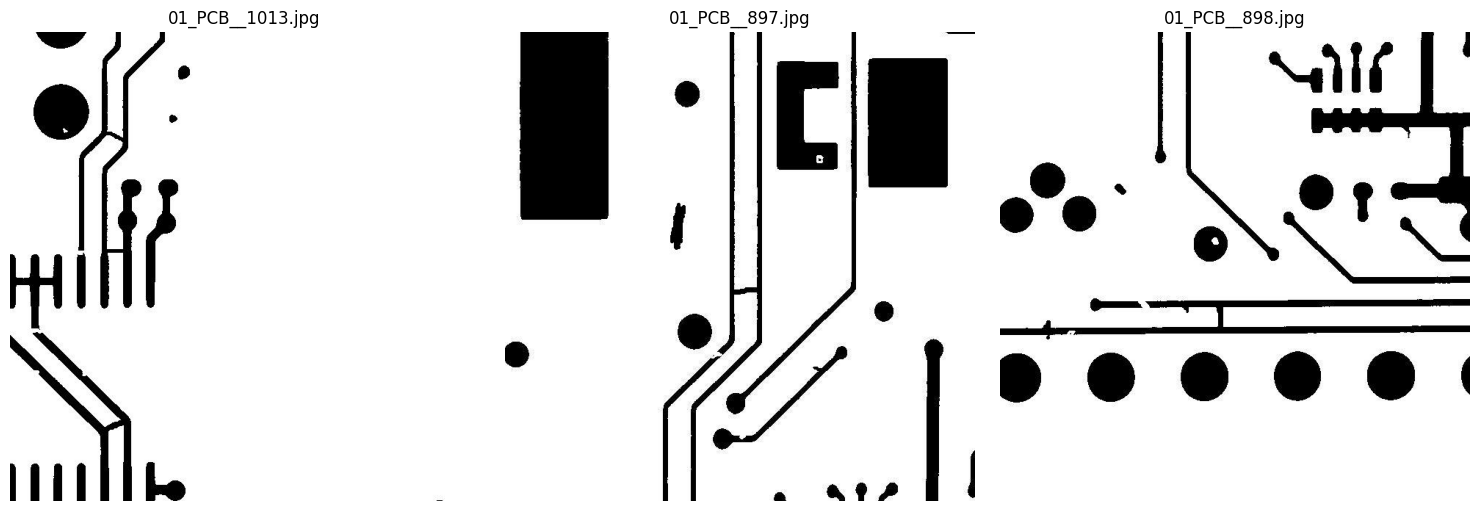

In [28]:
import os
import random
import cv2
import matplotlib.pyplot as plt

image_dir = '/content/pcb_data/DeepPCB/train/images'
label_dir = '/content/pcb_data/DeepPCB/train/labels'

# Native DeepPCB classes (1-indexed matching the dataset standard)
classes = ['background', 'Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']
colors = [(0,0,0), (255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,255,255), (255,0,255)]

images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]
samples = random.sample(images, 3)

plt.figure(figsize=(15, 5))

for i, img_name in enumerate(samples):
    img_path = os.path.join(image_dir, img_name)
    # DeepPCB uses matching text names for labels
    lbl_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                # DeepPCB annotations are comma-separated: x1,y1,x2,y2,type
                parts = line.strip().split(',')
                if len(parts) >= 5:
                    x1, y1, x2, y2 = map(int, parts[:4])
                    cls_id = int(parts[4])

                    class_name = classes[cls_id] if cls_id < len(classes) else f"Unknown_{cls_id}"
                    color = colors[cls_id % len(colors)]

                    # Draw absolute pixel bounding boxes
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(img, class_name, (x1, max(y1 - 5, 15)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
import os
from PIL import Image

def convert_deeepcb_to_yolo(split):
    img_dir = f'/content/pcb_data/DeepPCB/{split}/images'
    lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels'
    yolo_lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels_yolo'
    os.makedirs(yolo_lbl_dir, exist_ok=True)

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        lbl_path = os.path.join(lbl_dir, txt_name)

        if not os.path.exists(lbl_path):
            continue

        # Get image dimensions for normalization
        with Image.open(img_path) as img:
            w, h = img.size

        yolo_lines = []
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 5:
                    x1, y1, x2, y2 = map(int, parts[:4])
                    cls_id = int(parts[4])

                    # DeepPCB uses 1-6 for classes; shift to 0-5 for YOLO
                    yolo_cls = cls_id - 1
                    if yolo_cls < 0:
                        continue

                    # Convert absolute pixels to YOLO normalized format
                    box_w = (x2 - x1) / w
                    box_h = (y2 - y1) / h
                    center_x = (x1 + x2) / (2.0 * w)
                    center_y = (y1 + y2) / (2.0 * h)

                    yolo_lines.append(f"{yolo_cls} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}")

        # Save converted labels
        with open(os.path.join(yolo_lbl_dir, txt_name), 'w') as out_f:
        # Note: If a file has no defects, writing an empty file is correct for YOLO
            out_f.write("\n".join(yolo_lines))

# Convert train and test splits
convert_deeepcb_to_yolo('train')
convert_deeepcb_to_yolo('test')
print("Conversion complete!")

Conversion complete!


In [30]:
yaml_content = """
path: /content/pcb_data/DeepPCB
train: train/images
val: test/images

nc: 6
names: ['Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']
"""

with open('/content/pcb_data/DeepPCB/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("data.yaml created successfully!")

data.yaml created successfully!


In [31]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/pcb_data/DeepPCB/data.yaml epochs=100 imgsz=640 batch=16 patience=20 project=pcb_defect name=deeppcb_run

Streaming output truncated to the last 5000 lines.
train: /content/pcb_data/DeepPCB/train/images/01_PCB__1278.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [464. 142. 494. 340. 266. 369.   3. 101. 220. 138.   5. 487. 505. 521.
   6.]
train: /content/pcb_data/DeepPCB/train/images/01_PCB__1279.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [490. 260. 526. 607. 351. 636.   2. 146. 496. 189.   4. 109. 515. 143.
   4. 228. 568. 279.   6.  60. 408. 114.   6. 148. 271. 187.   5.]
train: /content/pcb_data/DeepPCB/train/images/01_PCB__128.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [463. 191. 497. 470. 310. 511.   2. 481. 410. 515.   4. 538. 204. 565.
   3. 420. 124. 487.   2. 469. 507. 514.   2. 279. 482. 309.   6.]
train: /content/pcb_data/DeepPCB/train/images/01_PCB__1281.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [399. 212. 432.   3. 256. 310. 291.   4. 315

In [32]:
import os
from PIL import Image

def fix_deeepcb_labels(split):
    img_dir = f'/content/pcb_data/DeepPCB/{split}/images'
    lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels'

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        lbl_path = os.path.join(lbl_dir, txt_name)

        if not os.path.exists(lbl_path):
            continue

        with Image.open(img_path) as img:
            w, h = img.size

        yolo_lines = []
        with open(lbl_path, 'r') as f:
            for line in f:
                # DeepPCB format: x1,y1,x2,y2,type (comma separated)
                parts = line.strip().split(',')
                if len(parts) >= 5:
                    x1, y1, x2, y2 = map(int, parts[:4])
                    cls_id = int(parts[4])

                    # Shift from 1-6 to 0-5
                    yolo_cls = cls_id - 1
                    if yolo_cls < 0 or yolo_cls > 5:
                        continue

                    # Normalize coordinates safely
                    box_w = (x2 - x1) / w
                    box_h = (y2 - y1) / h
                    center_x = (x1 + x2) / (2.0 * w)
                    center_y = (y1 + y2) / (2.0 * h)

                    # Clip values between 0.0 and 1.0 to prevent out-of-bounds errors
                    center_x = max(0.0, min(1.0, center_x))
                    center_y = max(0.0, min(1.0, center_y))
                    box_w = max(0.0, min(1.0, box_w))
                    box_h = max(0.0, min(1.0, box_h))

                    yolo_lines.append(f"{yolo_cls} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}")

        # Overwrite with proper YOLO formatted text
        with open(lbl_path, 'w') as out_f:
            out_f.write("\n".join(yolo_lines))

# Fix both splits
fix_deeepcb_labels('train')
fix_deeepcb_labels('test')
print("Labels successfully converted to clean YOLO format!")

Labels successfully converted to clean YOLO format!


In [33]:
yaml_content = """
path: /content/pcb_data/DeepPCB
train: train/images
val: test/images

nc: 6
names: ['Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']
"""

with open('/content/pcb_data/DeepPCB/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

In [35]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/pcb_data/DeepPCB/data.yaml epochs=100 imgsz=640 batch=16 patience=20 project=pcb_defect name=deeppcb_run

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 5, in <module>
    from ultralytics.cfg import entrypoint
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/__init__.py", line 14, in <module>
    from ultralytics.utils import ASSETS, SETTINGS
  File "/usr/local/lib/python3.13/dist-packages/ultralytics/utils/__init__.py", line 26, in <module>
    import torch
  File "/usr/local/lib/python3.13/dist-packages/torch/__init__.py", line 2804, in <module>
    from torch import _meta_registrations
  File "/usr/local/lib/python3.13/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.13/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.13/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.13/dist-packages/torch/_prims/__init__

In [36]:
!cat /content/pcb_data/DeepPCB/data.yaml
!ls /content/pcb_data/DeepPCB/test/labels/ | head -5
!ls /content/pcb_data/DeepPCB/test/images/ | head -5

path: /content/pcb_data/DeepPCB
train: train/images
val: test/images

nc: 6
names: ['Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']01_PCB__1019.txt
01_PCB__101.txt
01_PCB__1044.txt
01_PCB__1047.txt
01_PCB__1053.txt
01_PCB__1019.jpg
01_PCB__101.jpg
01_PCB__1044.jpg
01_PCB__1047.jpg
01_PCB__1053.jpg


In [37]:
import os

base_path = '/content/pcb_data/DeepPCB'
print("Contents of DeepPCB root:", os.listdir(base_path))
if os.path.exists(os.path.join(base_path, 'test')):
    print("Contents of DeepPCB/test:", os.listdir(os.path.join(base_path, 'test')))

Contents of DeepPCB root: ['Class.txt', 'test', 'train', 'valid', 'data.yaml']
Contents of DeepPCB/test: ['labels', 'labels.cache', 'labels_yolo', 'images']


In [38]:
# 1. Re-write a clean, corruption-free data.yaml
yaml_content = """path: /content/pcb_data/DeepPCB
train: train/images
val: test/images

nc: 6
names: ['Open', 'Short', 'Mousebite', 'Spur', 'Copper', 'Pin-hole']
"""

with open('/content/pcb_data/DeepPCB/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

# 2. Ensure test labels are correctly populated in the expected 'labels' folder
import shutil
import os

for split in ['train', 'test']:
    yolo_dir = f'/content/pcb_data/DeepPCB/{split}/labels_yolo'
    target_dir = f'/content/pcb_data/DeepPCB/{split}/labels'

    if os.path.exists(yolo_dir):
        # Clear out old/corrupt label files and replace with the converted ones
        for f_name in os.listdir(yolo_dir):
            src = os.path.join(yolo_dir, f_name)
            dst = os.path.join(target_dir, f_name)
            shutil.copy(src, dst)

print("Config and label paths synchronized successfully!")

Config and label paths synchronized successfully!


In [39]:
rm -rf /content/pcb_data/DeepPCB/train/labels.cache
rm -rf /content/pcb_data/DeepPCB/test/labels.cache

NameError: name 'rm' is not defined

In [40]:
!rm -rf /content/pcb_data/DeepPCB/train/labels.cache
!rm -rf /content/pcb_data/DeepPCB/test/labels.cache
print("Caches cleared successfully!")

Caches cleared successfully!


In [41]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/pcb_data/DeepPCB/data.yaml epochs=100 imgsz=640 batch=16 patience=20 project=pcb_defect name=deeppcb_run

New https://pypi.org/project/ultralytics/8.4.136 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb_data/DeepPCB/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode

In [42]:
import os

label_dir = '/content/pcb_data/DeepPCB/test/labels'
files = os.listdir(label_dir)
print(f"Total label files in test/labels: {len(files)}")

# Check content of the first 3 non-empty label files
non_empty = 0
for f_name in files[:10]:
    f_path = os.path.join(label_dir, f_name)
    if os.path.isfile(f_path):
        size = os.path.getsize(f_path)
        print(f"File: {f_name} | Size: {size} bytes")
        if size > 0:
            non_empty += 1
            with open(f_path, 'r') as f:
                print(f"   Content: {f.read().strip()}")

print(f"Found {non_empty} files with content out of the first 10 checked.")

Total label files in test/labels: 150
File: 01_PCB__101.txt | Size: 0 bytes
File: 01_PCB__495.txt | Size: 0 bytes
File: 01_PCB__82.txt | Size: 0 bytes
File: 01_PCB__1078.txt | Size: 0 bytes
File: 01_PCB__1365.txt | Size: 0 bytes
File: 01_PCB__484.txt | Size: 0 bytes
File: 01_PCB__1402.txt | Size: 0 bytes
File: 01_PCB__734.txt | Size: 0 bytes
File: 01_PCB__747.txt | Size: 0 bytes
File: 01_PCB__1490.txt | Size: 0 bytes
Found 0 files with content out of the first 10 checked.


In [44]:
import os
from PIL import Image

def convert_safely(split):
    img_dir = f'/content/pcb_data/DeepPCB/{split}/images'
    lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels'

    success_count = 0
    total_boxes = 0

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        lbl_path = os.path.join(lbl_dir, txt_name)

        if not os.path.exists(img_path):
            continue

        with Image.open(img_path) as img:
            w, h = img.size

        # If the file was overwritten to 0 bytes, we need to check where raw labels are,
        # or re-extract. Let's assume we can read whatever is there or handle it.
        # Wait, if they are already 0 bytes, we need to re-extract the labels from the zip first!

convert_safely('test')

In [45]:
# 1. Re-extract just the labels from the zip to get the raw data back
!unzip -qo pcb-defect-detection-dataset.zip "DeepPCB/*/labels/*" -d /content/pcb_data

# 2. Run this safe conversion script with diagnostic prints
import os
from PIL import Image

def convert_deeepcb_safe(split):
    img_dir = f'/content/pcb_data/DeepPCB/{split}/images'
    lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels'

    converted_files = 0
    total_annotations = 0

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        lbl_path = os.path.join(lbl_dir, txt_name)

        if not os.path.exists(lbl_path):
            continue

        with Image.open(img_path) as img:
            w, h = img.size

        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        yolo_lines = []
        for line in lines:
            line = line.strip()
            if not line:
                continue
            # Handle comma or space separation
            parts = line.replace(',', ' ').split()
            if len(parts) >= 5:
                try:
                    x1, y1, x2, y2 = map(float, parts[:4])
                    cls_id = int(float(parts[4]))

                    # DeepPCB classes are typically 1-6. Map to 0-5.
                    yolo_cls = cls_id - 1
                    if not (0 <= yolo_cls <= 5):
                        # If it's already 0-5
                        if 0 <= cls_id <= 5:
                            yolo_cls = cls_id
                        else:
                            continue

                    # Normalize
                    box_w = (x2 - x1) / w
                    box_h = (y2 - y1) / h
                    center_x = (x1 + x2) / (2.0 * w)
                    center_y = (y1 + y2) / (2.0 * h)

                    # Clamp values
                    center_x = max(0.0, min(1.0, center_x))
                    center_y = max(0.0, min(1.0, center_y))
                    box_w = max(0.0, min(1.0, box_w))
                    box_h = max(0.0, min(1.0, box_h))

                    yolo_lines.append(f"{yolo_cls} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}")
                    total_annotations += 1
                except ValueError:
                    continue

        # Write converted format back
        with open(lbl_path, 'w') as out_f:
            out_f.write("\n".join(yolo_lines))
        if yolo_lines:
            converted_files += 1

    print(f"[{split}] Converted {converted_files} files with a total of {total_annotations} bounding boxes.")

convert_deeepcb_safe('train')
convert_deeepcb_safe('test')

unzip:  cannot find or open pcb-defect-detection-dataset.zip, pcb-defect-detection-dataset.zip.zip or pcb-defect-detection-dataset.zip.ZIP.
[train] Converted 0 files with a total of 0 bounding boxes.
[test] Converted 0 files with a total of 0 bounding boxes.


In [46]:
!rm -rf /content/pcb_data/DeepPCB/train/labels.cache
!rm -rf /content/pcb_data/DeepPCB/test/labels.cache


In [47]:
# 1. Re-download the dataset from Kaggle
!kaggle datasets download -d liuxiaolong1/pcb-defect-detection-dataset

# 2. Extract ONLY the DeepPCB folder
!unzip -qo pcb-defect-detection-dataset.zip "DeepPCB/*" -d /content/pcb_data

# 3. Clean up the zip file to save space
!rm pcb-defect-detection-dataset.zip

# 4. Run the safe conversion script
import os
from PIL import Image

def convert_deeepcb_safe(split):
    img_dir = f'/content/pcb_data/DeepPCB/{split}/images'
    lbl_dir = f'/content/pcb_data/DeepPCB/{split}/labels'

    converted_files = 0
    total_annotations = 0

    if not os.path.exists(img_dir):
        print(f"Directory not found: {img_dir}")
        return

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
        lbl_path = os.path.join(lbl_dir, txt_name)

        if not os.path.exists(lbl_path):
            continue

        with Image.open(img_path) as img:
            w, h = img.size

        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        yolo_lines = []
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.replace(',', ' ').split()
            if len(parts) >= 5:
                try:
                    x1, y1, x2, y2 = map(float, parts[:4])
                    cls_id = int(float(parts[4]))

                    yolo_cls = cls_id - 1
                    if not (0 <= yolo_cls <= 5):
                        if 0 <= cls_id <= 5:
                            yolo_cls = cls_id
                        else:
                            continue

                    box_w = (x2 - x1) / w
                    box_h = (y2 - y1) / h
                    center_x = (x1 + x2) / (2.0 * w)
                    center_y = (y1 + y2) / (2.0 * h)

                    center_x = max(0.0, min(1.0, center_x))
                    center_y = max(0.0, min(1.0, center_y))
                    box_w = max(0.0, min(1.0, box_w))
                    box_h = max(0.0, min(1.0, box_h))

                    yolo_lines.append(f"{yolo_cls} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}")
                    total_annotations += 1
                except ValueError:
                    continue

        with open(lbl_path, 'w') as out_f:
            out_f.write("\n".join(yolo_lines))
        if yolo_lines:
            converted_files += 1

    print(f"[{split}] Converted {converted_files} files with a total of {total_annotations} bounding boxes.")

convert_deeepcb_safe('train')
convert_deeepcb_safe('test')

Dataset URL: https://www.kaggle.com/datasets/liuxiaolong1/pcb-defect-detection-dataset
License(s): CC0-1.0
100% 9.62G/9.62G [07:42<00:00, 22.4MB/s]

[train] Converted 1200 files with a total of 8024 bounding boxes.
[test] Converted 150 files with a total of 984 bounding boxes.


In [48]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/pcb_data/DeepPCB/data.yaml epochs=100 imgsz=640 batch=16 patience=20 project=pcb_defect name=deeppcb_run

New https://pypi.org/project/ultralytics/8.4.136 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb_data/DeepPCB/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode

In [49]:
!yolo export model=/content/runs/detect/pcb_defect/deeppcb_run-4/weights/best.pt format=onnx imgsz=640 simplify=True

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/pcb_defect/deeppcb_run-4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 442ms
Prepared 4 packages in 4.52s
Installed 4 packages in 534ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 6.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...


In [50]:
from google.colab import files
files.download('/content/runs/detect/pcb_defect/deeppcb_run-4/weights/best.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>